In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("E:\Quant_fin\Experiments\Portfolio\Montecarlo_simulation\ledger.csv")


# Performance Plot

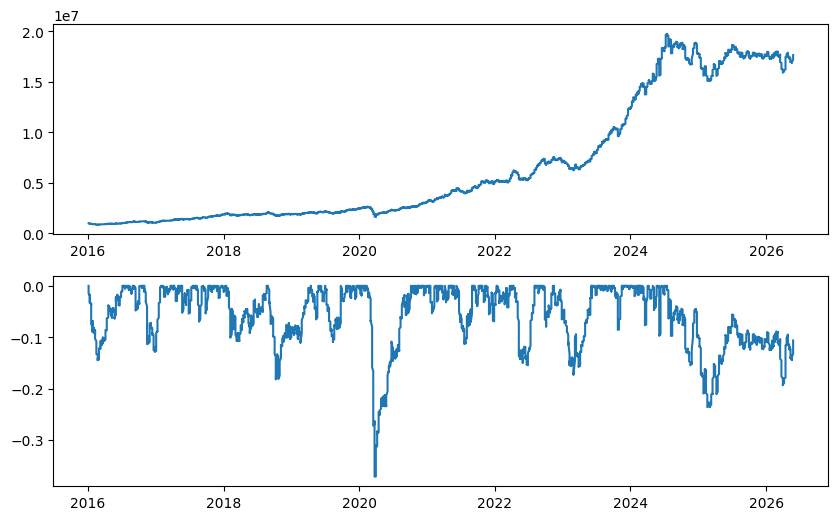

In [16]:
performance_df = data.copy()
performance_df.index= pd.to_datetime(data['Exit_date'])
roll_max = performance_df['equity_curve'].cummax()
max_dd = (performance_df['equity_curve']/roll_max)-1
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(10, 6))
ax1.plot(performance_df['equity_curve'], label='Equity Curve')
ax2.plot(max_dd, label='Draw down Curve')
plt.show()

# Portfolio- Value at Risk (VaR)

## Historic VaR

In [4]:
portfolio_level_df = data.copy()

In [5]:
portfolio_level_df.index = pd.to_datetime(portfolio_level_df['Exit_date'])

In [6]:
portfolio__curve = portfolio_level_df[['equity_curve','Exit_date']].copy()

In [7]:
portfolio__curve = portfolio__curve.resample("W").last()

In [8]:
portfolio__curve['return'] = list(portfolio__curve['equity_curve'].pct_change())
low, high= portfolio__curve['return'].quantile([1-.95,1-.99])
conditional_var = portfolio__curve[portfolio__curve['return']<low]['return'].mean()
conditional_var

np.float64(-0.06592120919735354)

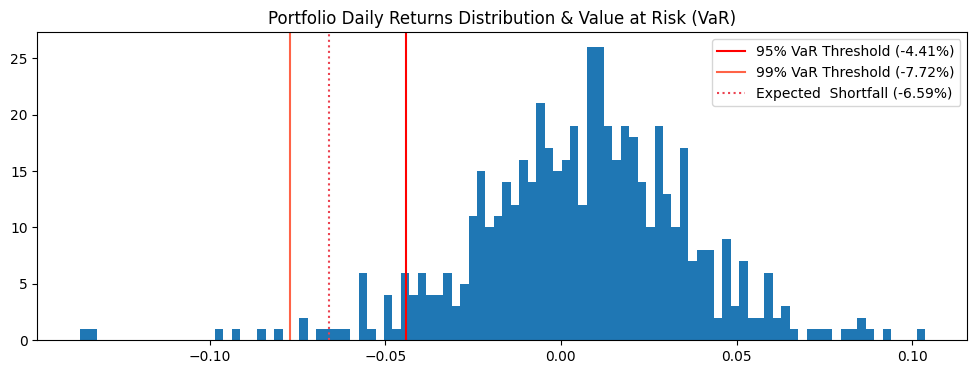

In [9]:
plt.figure(figsize=(12,4))
plt.hist(x=portfolio__curve['return'],bins=100)
plt.title('Portfolio Daily Returns Distribution & Value at Risk (VaR)')
plt.axvline(x=low, color="red", label=f'95% VaR Threshold ({low:.2%})')
plt.axvline(x=high, color="tomato",label=f'99% VaR Threshold ({high:.2%})')
plt.axvline(x=conditional_var,color="#ec4250",linestyle=":", label=f'Expected  Shortfall ({conditional_var:.2%})')
plt.legend()
plt.show()

## Monte Carlo Resampling

In [10]:
number_of_simulation = 50 # For 1000 Simulations
array = []
for a in range(number_of_simulation):
    sample = np.random.choice(
        portfolio__curve['return'].to_list(),
        size=100, 
        replace=True
    )
    array.append(sample.cumsum()+1)


In [11]:
equity_curve = pd.DataFrame(array)
equity_curve = equity_curve.cumsum(1)
equity_curve.isna().sum().sum()

np.int64(333)

In [12]:
equity_curve.ffill(inplace=True)
equity_curve.fillna(0)
equity_curve.isna().sum().sum()


np.int64(0)

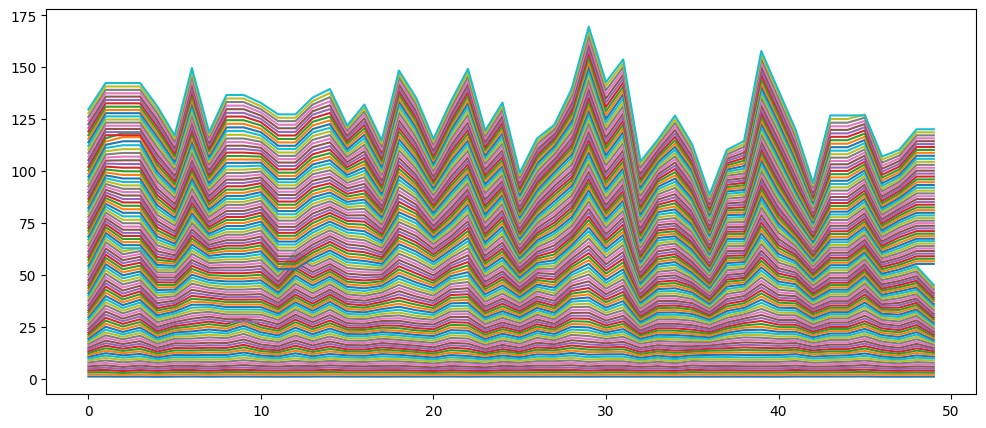

In [13]:
plt.figure(figsize=[12,5])
plt.plot(equity_curve)
plt.show()